In [1]:
import netCDF4 as nc
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import copy

In [2]:
import gc
gc.enable()

In [3]:
def find_files(directory, string):
    matches = []
    for root, dirnames, filenames in os.walk(directory):
        for filename in filenames:
            if string in filename and filename.endswith('.nc'):
                matches.append(os.path.join(root, filename))
    return matches

def concatenate_stack_datasets(center_ds, before_ds, after_ds):
    """
    Concatenates three xarray datasets together along the time dimension.

    Parameters
    ----------
    center_ds : xarray.Dataset
        The main dataset to concatenate.
    before_ds : xarray.Dataset
        The dataset containing the time steps before center_ds.
    after_ds : xarray.Dataset
        The dataset containing the time steps after center_ds.

    Returns
    -------
    xarray.Dataset
        The concatenated dataset.
    """
    
    s_before_ds = stack_dataset(before_ds)
    s_center_ds = stack_dataset(center_ds)
    s_after_ds = stack_dataset(after_ds)

    # Concatenate the datasets along the time dimension
    ds_list = [s_before_ds, s_center_ds, s_after_ds]
    ds = xr.concat(ds_list, dim='time')

    return ds

def stack_dataset(ds):
    ds_stacked = ds.stack(time=('forecast_initial_time', 'forecast_hour'))
    time_arr = pd.to_datetime([t[0] + pd.Timedelta(t[1],unit='hour') for t in ds_stacked.time.data])
    ds_stacked = ds_stacked.drop_vars({'time','forecast_hour', 'forecast_initial_time'})
    ds_stacked = ds_stacked.assign_coords(time=time_arr)
    return ds_stacked

def cut_and_select(ds, var_name, lat_range, lon_range):
    """
    Cut a rectangular region defined by latitude and longitude ranges from a dataset, and
    select one variable of interest.

    Parameters
    ----------
    ds : xarray.Dataset
        The input dataset containing the variable of interest and the latitude and longitude
        coordinates.
    var_name : str
        The name of the variable to select.
    lat_range : tuple of two floats
        The latitude range to cut, defined as (min_lat, max_lat).
    lon_range : tuple of two floats
        The longitude range to cut, defined as (min_lon, max_lon).

    Returns
    -------
    xarray.Dataset
        A new dataset containing only the selected variable, with the corresponding latitude
        and longitude coordinates.
    """
    # Select the variable of interest
    var = ds[var_name]

    # Cut the rectangular region based on the latitude and longitude ranges
    var_cut = var.sel(latitude=slice(lat_range[1],lat_range[0]), longitude=slice(lon_range[0], lon_range[1]))

    # Create a new dataset with only the selected variable and its coordinates
    ds_var = xr.Dataset({var_name: var_cut})

    return ds_var


In [4]:
path_outputs_daily = '/glade/work/jhayron/Data4Predictability/ERA5/Daily/'

# Land variables

In [5]:
path_mask = '/glade/work/jhayron/Data4Predictability/ERA5/e5.oper.invariant.128_172_lsm.ll025sc.1979010100_1979010100.nc'

In [6]:
ds_mask = xr.open_dataset(path_mask)

In [7]:
mask_ocean = ds_mask.LSM.data[0]
mask_ocean[mask_ocean==0] = np.nan

In [8]:
mask_ocean.shape

(721, 1440)

# SWVL 4

In [9]:
path_data_era5 = '/glade/campaign/collections/rda/data/ds633.0/'

list_variables_land = ['swvl4']
subfolders = ['e5.oper.an.sfc']
codename = ['.128_042_swvl4.ll025sc.']
# level = [None, 10, 200, 500]
var_name = ['SWVL4']

In [ ]:
ivar = 0
lat_range = (-30,90)
lon_range = (0,360)
list_files = np.sort(find_files(f'{path_data_era5}{subfolders[ivar]}/',codename[ivar]))
# list_files = list_files[480:]
# list_files = list_files[828:935]
# list_files = list_files[861:935]
list_files = list_files[885:935]
# aaaa
# list_files = list_files[897:935]
for ifile in range(len(list_files)):
    if ifile%100 == 0:
        print(list_files[ifile])

    if os.path.exists(path_outputs_daily+f'{var_name[ivar]}/') == False:
        os.mkdir(path_outputs_daily+f'{var_name[ivar]}/')

    for ifile in range(len(list_files)):
        # print(list_files[ifile])
        ds_temp = xr.open_dataset(list_files[ifile])   
        ds_temp[var_name[ivar]].data = ds_temp[var_name[ivar]].data * mask_ocean
        ds_temp = cut_and_select(ds_temp,var_name[ivar],lat_range,lon_range)

        ds_moisture_daily = ds_temp.resample(time='D').mean(dim='time')

        if os.path.exists(path_outputs_daily+f'{var_name[0]}/') == False:
            os.mkdir(path_outputs_daily+f'{var_name[0]}/')
            
        for itime in range(len(ds_moisture_daily.time)):
            ds_temp_daily = ds_moisture_daily.isel(time = itime)
            str_date = ds_moisture_daily.time.data[()].astype(str)[itime][:10]
            output_path =  path_outputs_daily+f'{var_name[ivar]}/{var_name[ivar]}_Daily_'+str_date+'.nc'
            ds_temp_daily.to_netcdf(output_path)
        gc.collect()

/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201310/e5.oper.an.sfc.128_042_swvl4.ll025sc.2013100100_2013103123.nc


In [12]:
list_files[885:]

array(['/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201310/e5.oper.an.sfc.128_042_swvl4.ll025sc.2013100100_2013103123.nc',
       '/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201311/e5.oper.an.sfc.128_042_swvl4.ll025sc.2013110100_2013113023.nc',
       '/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201312/e5.oper.an.sfc.128_042_swvl4.ll025sc.2013120100_2013123123.nc',
       '/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201401/e5.oper.an.sfc.128_042_swvl4.ll025sc.2014010100_2014013123.nc',
       '/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201402/e5.oper.an.sfc.128_042_swvl4.ll025sc.2014020100_2014022823.nc',
       '/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201403/e5.oper.an.sfc.128_042_swvl4.ll025sc.2014030100_2014033123.nc',
       '/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201404/e5.oper.an.sfc.128_042_swvl4.ll025sc.2014040100_2014043023.nc',
       '/glade/campaign/col

# SWVL 3

In [9]:
path_data_era5 = '/glade/campaign/collections/rda/data/ds633.0/'

list_variables_land = ['swvl3']
subfolders = ['e5.oper.an.sfc']
codename = ['.128_041_swvl3.ll025sc.']
# level = [None, 10, 200, 500]
var_name = ['SWVL3']

In [ ]:
ivar = 0
lat_range = (-30,90)
lon_range = (0,360)
list_files = np.sort(find_files(f'{path_data_era5}{subfolders[ivar]}/',codename[ivar]))
# list_files = list_files[480:]
# list_files = list_files[828:935]
# list_files = list_files[861:935]
list_files = list_files[897:935]

for ifile in range(len(list_files)):
    if ifile%100 == 0:
        print(list_files[ifile])

    if os.path.exists(path_outputs_daily+f'{var_name[ivar]}/') == False:
        os.mkdir(path_outputs_daily+f'{var_name[ivar]}/')

    for ifile in range(len(list_files)):
        # print(list_files[ifile])
        ds_temp = xr.open_dataset(list_files[ifile])   
        ds_temp[var_name[ivar]].data = ds_temp[var_name[ivar]].data * mask_ocean
        ds_temp = cut_and_select(ds_temp,var_name[ivar],lat_range,lon_range)

        ds_moisture_daily = ds_temp.resample(time='D').mean(dim='time')

        if os.path.exists(path_outputs_daily+f'{var_name[0]}/') == False:
            os.mkdir(path_outputs_daily+f'{var_name[0]}/')
            
        for itime in range(len(ds_moisture_daily.time)):
            ds_temp_daily = ds_moisture_daily.isel(time = itime)
            str_date = ds_moisture_daily.time.data[()].astype(str)[itime][:10]
            output_path =  path_outputs_daily+f'{var_name[ivar]}/{var_name[ivar]}_Daily_'+str_date+'.nc'
            ds_temp_daily.to_netcdf(output_path)
        gc.collect()

/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/201410/e5.oper.an.sfc.128_041_swvl3.ll025sc.2014100100_2014103123.nc


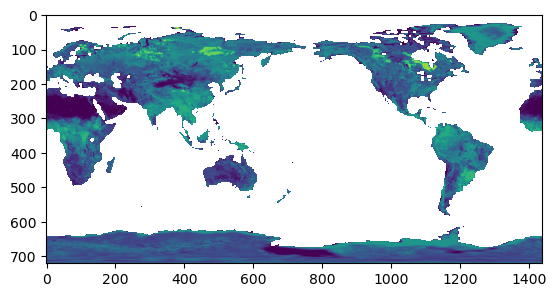

In [33]:
plt.imshow(ds_temp[var_name[ivar]].isel(time=0).data * mask_ocean)

In [51]:
plt.imshow(ds_temp[var_name[ivar]].isel(time=0).data)

'2009-01-01'

In [48]:
path_outputs_daily+f'{var_name[ivar]}/{var_name[ivar]}_Daily_{str_date}.nc'

"/glade/work/jhayron/Data4Predictability/ERA5/Daily/SWVL3/SWVL3_Daily_['2009-01-01T00:00:00.000000000' '2009-01-02T00:00:00.000000000'\n '2009-01-03T00:00:00.000000000' '2009-01-04T00:00:00.000000000'\n '2009-01-05T00:00:00.000000000' '2009-01-06T00:00:00.000000000'\n '2009-01-07T00:00:00.000000000' '2009-01-08T00:00:00.000000000'\n '2009-01-09T00:00:00.000000000' '2009-01-10T00:00:00.000000000'].nc"

## Land moisture

In [9]:
path_data_era5 = '/gpfs/fs1/collections/rda/data/ds633.0/'

list_variables_moisture = ['swvl1','swvl2','swvl3','swvl4']
subfolders = ['e5.oper.an.sfc','e5.oper.an.sfc','e5.oper.an.sfc','e5.oper.an.sfc']
codename = ['.128_039_swvl1.ll025sc.','.128_040_swvl2.ll025sc.','.128_041_swvl3.ll025sc.','.128_042_swvl4.ll025sc.']
depth = [0.07, 0.21, 0.72, 1.89]
var_name = ['SWVL1','SWVL2','SWVL3','SWVL4']

ivar = 0
lat_range = (-30,90)
lon_range = (0,360)

list_files_0 = np.sort(find_files(f'{path_data_era5}{subfolders[ivar]}/',codename[ivar]))
list_files_0 = list_files_0[480:]


In [ ]:
for ifile in range(len(list_files_0)):
    if ifile%100 == 0:
        print(list_files_0[ifile])
    ds_moisture = []
    for ivar in range(len(list_variables_moisture)):
        list_files = np.sort(find_files(f'{path_data_era5}{subfolders[ivar]}/',codename[ivar]))
        list_files = list_files[480:]
        ds_temp = xr.open_dataset(list_files[ifile])
        ds_temp = ds_temp.resample(time='D').mean(dim='time')
        ds_moisture.append(ds_temp)
        
    ds_moisture = xr.merge(ds_moisture)
    ds_moisture_daily = copy.deepcopy(ds_moisture)
    del(ds_moisture)
    for itime in range(len(ds_moisture_daily.time)):
        ds_temp_daily = ds_moisture_daily.isel(time = itime)
        str_date = ds_temp_daily.time.data[()].astype(str)[:10]

#         average_moisture_full = ((ds_temp_daily[var_name[0]] * depth[0] + 
#                            ds_temp_daily[var_name[1]] * depth[1] + 
#                            ds_temp_daily[var_name[2]] * depth[2] + 
#                            ds_temp_daily[var_name[3]] * depth[3]) / np.sum(depth)).to_dataset(name='SWVL_full')
#         average_moisture_full['SWVL_full'].attrs['units'] = 'm**3 m**-3'

#         average_moisture_1m = ((ds_temp_daily[var_name[0]] * depth[0] + 
#                            ds_temp_daily[var_name[1]] * depth[1] + 
#                            ds_temp_daily[var_name[2]] * depth[2]) / np.sum(depth[:-1])).to_dataset(name='SWVL_1m')
#         average_moisture_1m['SWVL_1m'].attrs['units'] = 'm**3 m**-3'
        
        average_moisture_28cm = ((ds_temp_daily[var_name[0]] * depth[0] + 
                           ds_temp_daily[var_name[1]] * depth[1]) / np.sum(depth[:-2])).to_dataset(name='SWVL_28cm')
        average_moisture_28cm['SWVL_28cm'].attrs['units'] = 'm**3 m**-3'

        average_moisture_7cm = ((ds_temp_daily[var_name[0]] * depth[0]) / np.sum(depth[:-3])).to_dataset(name='SWVL_7cm')
        average_moisture_7cm['SWVL_7cm'].attrs['units'] = 'm**3 m**-3'

        # average_moisture_full.SWVL_full.data = average_moisture_full.SWVL_full.data * mask_ocean
        # average_moisture_1m.SWVL_1m.data = average_moisture_1m.SWVL_1m.data * mask_ocean
        average_moisture_28cm.SWVL_28cm.data = average_moisture_28cm.SWVL_28cm.data * mask_ocean
        average_moisture_7cm.SWVL_7cm.data = average_moisture_7cm.SWVL_7cm.data * mask_ocean

#         if os.path.exists(path_outputs_daily+f'SWVL_full/') == False:
#             os.mkdir(path_outputs_daily+f'SWVL_full/')

#         if os.path.exists(path_outputs_daily+f'SWVL_1m/') == False:
#             os.mkdir(path_outputs_daily+f'SWVL_1m/')
            
        if os.path.exists(path_outputs_daily+f'SWVL_28cm/') == False:
            os.mkdir(path_outputs_daily+f'SWVL_28cm/')

        if os.path.exists(path_outputs_daily+f'SWVL_7cm/') == False:
            os.mkdir(path_outputs_daily+f'SWVL_7cm/')

#         output_path_full =  path_outputs_daily+f'SWVL_full/SWVL_full_Daily_'+str_date+'.nc'
#         average_moisture_full = cut_and_select(average_moisture_full,'SWVL_full',lat_range,lon_range)
#         average_moisture_full.to_netcdf(output_path_full)

#         output_path_1m =  path_outputs_daily+f'SWVL_1m/SWVL_1m_Daily_'+str_date+'.nc'
#         average_moisture_1m = cut_and_select(average_moisture_1m,'SWVL_1m',lat_range,lon_range)
#         average_moisture_1m.to_netcdf(output_path_1m)
        
        output_path_28cm =  path_outputs_daily+f'SWVL_28cm/SWVL_28cm_Daily_'+str_date+'.nc'
        average_moisture_28cm = cut_and_select(average_moisture_28cm,'SWVL_28cm',lat_range,lon_range)
        average_moisture_28cm.to_netcdf(output_path_28cm)

        output_path_7cm =  path_outputs_daily+f'SWVL_7cm/SWVL_7cm_Daily_'+str_date+'.nc'
        average_moisture_7cm = cut_and_select(average_moisture_7cm,'SWVL_7cm',lat_range,lon_range)
        average_moisture_7cm.to_netcdf(output_path_7cm)

/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198001/e5.oper.an.sfc.128_039_swvl1.ll025sc.1980010100_1980013123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198805/e5.oper.an.sfc.128_039_swvl1.ll025sc.1988050100_1988053123.nc


## Land temperature

In [12]:
path_data_era5 = '/gpfs/fs1/collections/rda/data/ds633.0/'

list_variables_temperature = ['stl1','stl2','stl3','stl4']
subfolders = ['e5.oper.an.sfc','e5.oper.an.sfc','e5.oper.an.sfc','e5.oper.an.sfc']
codename = ['.128_139_stl1.ll025sc.','.128_170_stl2.ll025sc.','.128_183_stl3.ll025sc.','.128_236_stl4.ll025sc.']
depth = [0.07, 0.21, 0.72, 1.89]
var_name = ['STL1','STL2','STL3','STL4']

ivar = 0
lat_range = (-30,90)
lon_range = (0,360)

list_files = np.sort(find_files(f'{path_data_era5}{subfolders[ivar]}/',codename[ivar]))
list_files = list_files[480:]

In [14]:
for ifile in range(len(list_files)):
    if ifile%100 == 0:
        print(list_files[ifile])
        
    ds_temperature = []
    for ivar in range(len(list_variables_temperature)):
        list_files = np.sort(find_files(f'{path_data_era5}{subfolders[ivar]}/',codename[ivar]))
        list_files = list_files[480:]
        ds_temp = xr.open_dataset(list_files[ifile])
        ds_temp = ds_temp.resample(time='D').mean(dim='time')
        ds_temperature.append(ds_temp)

    ds_temperature = xr.merge(ds_temperature)
    ds_temperature_daily = copy.deepcopy(ds_temperature)
    del(ds_temperature)
    
    for itime in range(len(ds_temperature_daily.time)):
        ds_temp_daily = ds_temperature_daily.isel(time = itime)
        str_date = ds_temp_daily.time.data[()].astype(str)[:10]

#         average_temperature_full = ((ds_temp_daily[var_name[0]] * depth[0] + 
#                            ds_temp_daily[var_name[1]] * depth[1] + 
#                            ds_temp_daily[var_name[2]] * depth[2] + 
#                            ds_temp_daily[var_name[3]] * depth[3]) / np.sum(depth)).to_dataset(name='STL_full')
#         average_temperature_full['STL_full'].attrs['units'] = 'K'

#         average_temperature_1m = ((ds_temp_daily[var_name[0]] * depth[0] + 
#                            ds_temp_daily[var_name[1]] * depth[1] + 
#                            ds_temp_daily[var_name[2]] * depth[2]) / np.sum(depth[:-1])).to_dataset(name='STL_1m')
#         average_temperature_1m['STL_1m'].attrs['units'] = 'K'
        
        average_temperature_28cm = ((ds_temp_daily[var_name[0]] * depth[0] + 
                           ds_temp_daily[var_name[1]] * depth[1]) / np.sum(depth[:-2])).to_dataset(name='STL_28cm')
        average_temperature_28cm['STL_28cm'].attrs['units'] = 'K'

        average_temperature_7cm = ((ds_temp_daily[var_name[0]] * depth[0]) / np.sum(depth[:-3])).to_dataset(name='STL_7cm')
        average_temperature_7cm['STL_7cm'].attrs['units'] = 'K'

        # average_temperature_full.STL_full.data = average_temperature_full.STL_full.data * mask_ocean
        # average_temperature_1m.STL_1m.data = average_temperature_1m.STL_1m.data * mask_ocean
        average_temperature_28cm.STL_28cm.data = average_temperature_28cm.STL_28cm.data * mask_ocean
        average_temperature_7cm.STL_7cm.data = average_temperature_7cm.STL_7cm.data * mask_ocean

#         if os.path.exists(path_outputs_daily+f'STL_full/') == False:
#             os.mkdir(path_outputs_daily+f'STL_full/')

#         if os.path.exists(path_outputs_daily+f'STL_1m/') == False:
#             os.mkdir(path_outputs_daily+f'STL_1m/')
            
        if os.path.exists(path_outputs_daily+f'STL_28cm/') == False:
            os.mkdir(path_outputs_daily+f'STL_28cm/')

        if os.path.exists(path_outputs_daily+f'STL_7cm/') == False:
            os.mkdir(path_outputs_daily+f'STL_7cm/')

#         output_path_full =  path_outputs_daily+f'STL_full/STL_full_Daily_'+str_date+'.nc'
#         average_temperature_full = cut_and_select(average_temperature_full,'STL_full',lat_range,lon_range)
#         average_temperature_full.to_netcdf(output_path_full)

#         output_path_1m =  path_outputs_daily+f'STL_1m/STL_1m_Daily_'+str_date+'.nc'
#         average_temperature_1m = cut_and_select(average_temperature_1m,'STL_1m',lat_range,lon_range)
#         average_temperature_1m.to_netcdf(output_path_1m)
        
        output_path_28cm =  path_outputs_daily+f'STL_28cm/STL_28cm_Daily_'+str_date+'.nc'
        average_temperature_28cm = cut_and_select(average_temperature_28cm,'STL_28cm',lat_range,lon_range)
        average_temperature_28cm.to_netcdf(output_path_28cm)

        output_path_7cm =  path_outputs_daily+f'STL_7cm/STL_7cm_Daily_'+str_date+'.nc'
        average_temperature_7cm = cut_and_select(average_temperature_7cm,'STL_7cm',lat_range,lon_range)
        average_temperature_7cm.to_netcdf(output_path_7cm)

/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198001/e5.oper.an.sfc.128_236_stl4.ll025sc.1980010100_1980013123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198805/e5.oper.an.sfc.128_236_stl4.ll025sc.1988050100_1988053123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/199609/e5.oper.an.sfc.128_236_stl4.ll025sc.1996090100_1996093023.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/200501/e5.oper.an.sfc.128_236_stl4.ll025sc.2005010100_2005013123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/201305/e5.oper.an.sfc.128_236_stl4.ll025sc.2013050100_2013053123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/202109/e5.oper.an.sfc.128_236_stl4.ll025sc.2021090100_2021093023.nc


# Snow depth

In [9]:
path_data_era5 = '/gpfs/fs1/collections/rda/data/ds633.0/'

list_variables_land = ['snow_depth']
subfolders = ['e5.oper.an.sfc']
codename = ['.128_141_sd.ll025sc.']
# level = [None, 10, 200, 500]
var_name = ['SD']

In [ ]:
ivar = 0
lat_range = (-30,90)
lon_range = (0,360)
list_files = np.sort(find_files(f'{path_data_era5}{subfolders[ivar]}/',codename[ivar]))
list_files = list_files[480:]

for ifile in range(len(list_files)):
    if ifile%100 == 0:
        print(list_files[ifile])

    if os.path.exists(path_outputs_daily+f'{var_name[ivar]}/') == False:
        os.mkdir(path_outputs_daily+f'{var_name[ivar]}/')

    for ifile in range(len(list_files)):
        print(list_files[ifile])
        ds_temp = xr.open_dataset(list_files[ifile])   
        ds_temp[var_name[ivar]].data = ds_temp[var_name[ivar]].data * mask_ocean
        ds_temp = cut_and_select(ds_temp,var_name[ivar],lat_range,lon_range)

        ds_snow_daily = ds_temp.resample(time='D').mean(dim='time')

        if os.path.exists(path_outputs_daily+f'SD/') == False:
            os.mkdir(path_outputs_daily+f'SD/')
            
        for itime in range(len(ds_snow_daily.time)):
            ds_temp_daily = ds_snow_daily.isel(time = itime)
            str_date = ds_temp_daily.time.data[()].astype(str)[:10]
            
            output_path =  path_outputs_daily+f'{var_name[ivar]}/{var_name[ivar]}_Daily_'+str_date+'.nc'
            ds_temp_daily.to_netcdf(output_path)

/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198005/e5.oper.an.sfc.128_141_sd.ll025sc.1980050100_1980053123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198006/e5.oper.an.sfc.128_141_sd.ll025sc.1980060100_1980063023.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198007/e5.oper.an.sfc.128_141_sd.ll025sc.1980070100_1980073123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198008/e5.oper.an.sfc.128_141_sd.ll025sc.1980080100_1980083123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198009/e5.oper.an.sfc.128_141_sd.ll025sc.1980090100_1980093023.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198010/e5.oper.an.sfc.128_141_sd.ll025sc.1980100100_1980103123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198011/e5.oper.an.sfc.128_141_sd.ll025sc.1980110100_1980113023.nc
/gpfs/fs1/collections/rda/data/ds633.0/e5.oper.an.sfc/198012/e5.oper.an.sfc.128_141_sd.ll025sc.1980120100_1980123123.nc
/gpfs/fs1/collections/rda/data/ds633.0/e

In [17]:
list_files[-1]

'/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.sfc/202309/e5.oper.an.sfc.128_041_swvl3.ll025sc.2023090100_2023093023.nc'